In [8]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Use white background (standard for printing)
plt.style.use('seaborn-v0_8-white') 

# Professional Fonts (Arial/Helvetica)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

print('✓ Setup complete')

✓ Setup complete


In [13]:
# Model definitions
MODELS = {
    'ba_vae': 'Beat-Aligned VAE',
    'cae': 'Convolutional AE',
    'hlvae': 'Hierarchical Latent VAE',
    'st_vae': 'ST-VAE',
    'vae_bilstm_attn': 'VAE BiLSTM Attn',
    'vae_bilstm_mha': 'VAE BiLSTM MHA',
    'vae_gru': 'VAE GRU'
}

def load_json(path):
    """Load model data from path"""
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"⚠ File not found: {path}")
        return None

print(f'✓ Loaded {len(MODELS)} model definitions')

✓ Loaded 7 model definitions


In [11]:
def plot_confusion_matrix(data, model_id, model_name):
    """
    Generates a CLEAN Confusion Matrix without borders.
    Size: (5, 4) - Perfect for fitting in text columns.
    """
    cm = data['confusion_matrix']
    confusion = np.array([
        [cm['TN'], cm['FP']],
        [cm['FN'], cm['TP']]
    ])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    
    # linewidths=0 removes the borders between cells
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', 
                cbar=True, square=True, 
                linewidths=0,  # <--- REMOVES BORDER
                xticklabels=['Normal', 'Abnormal'],
                yticklabels=['Normal', 'Abnormal'],
                annot_kws={'size': 14, 'weight': 'bold'},
                ax=ax)
    
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(f'{model_name}\nConfusion Matrix', pad=15, fontweight='bold')
    
    # Remove the bounding box for cleaner look
    sns.despine(left=True, bottom=True, top=True, right=True)

    # Save
    out_dir = Path(f'outputs/visualizations/{model_id}')
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_combined_training_curves(data, model_id, model_name):
    """
    Generates combined training curves with all loss components and learning rate.
    Size: (10, 8) - 2x2 grid for comprehensive view.
    """
    training = data['training']
    epochs = list(range(1, len(training['train_loss']) + 1))
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f'{model_name}: Training Analysis', fontweight='bold', fontsize=14)
    
    # 1. Total Loss
    ax1 = axes[0, 0]
    ax1.plot(epochs, training['train_loss'], label='Train Loss', 
            color='#1f77b4', linewidth=2, alpha=0.8)
    ax1.plot(epochs, training['val_loss'], label='Val Loss', 
            color='#d62728', linewidth=2, alpha=0.8)
    best_epoch = training.get('best_epoch', len(epochs))
    if best_epoch <= len(epochs):
        ax1.axvline(x=best_epoch, color='gold', linestyle='--', linewidth=2, 
                   alpha=0.7, label=f'Best Epoch: {best_epoch}')
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Total Loss (Log Scale)', fontweight='bold')
    ax1.set_title('Total Loss', fontweight='bold')
    ax1.legend(frameon=True)
    ax1.grid(True, alpha=0.2)
    ax1.set_yscale('log')
    sns.despine(ax=ax1)
    
    # 2. Reconstruction Loss
    ax2 = axes[0, 1]
    ax2.plot(epochs, training['train_recon'], label='Train Recon', 
            color='#1f77b4', linewidth=2, alpha=0.8)
    ax2.plot(epochs, training['val_recon'], label='Val Recon', 
            color='#d62728', linewidth=2, alpha=0.8)
    ax2.set_xlabel('Epochs', fontweight='bold')
    ax2.set_ylabel('Reconstruction Loss (Log Scale)', fontweight='bold')
    ax2.set_title('Reconstruction Loss', fontweight='bold')
    ax2.legend(frameon=True)
    ax2.grid(True, alpha=0.2)
    ax2.set_yscale('log')
    sns.despine(ax=ax2)
    
    # 3. KL Divergence
    ax3 = axes[1, 0]
    if max(training['train_kl']) > 0:
        ax3.plot(epochs, training['train_kl'], label='Train KL', 
                color='#1f77b4', linewidth=2, alpha=0.8)
        ax3.plot(epochs, training['val_kl'], label='Val KL', 
                color='#d62728', linewidth=2, alpha=0.8)
        ax3.set_xlabel('Epochs', fontweight='bold')
        ax3.set_ylabel('KL Divergence', fontweight='bold')
        ax3.set_title('KL Divergence', fontweight='bold')
        ax3.legend(frameon=True)
        ax3.grid(True, alpha=0.2)
        sns.despine(ax=ax3)
    else:
        ax3.text(0.5, 0.5, 'N/A\n(Non-VAE Model)', 
                ha='center', va='center', fontsize=14, fontweight='bold',
                transform=ax3.transAxes)
        ax3.set_title('KL Divergence', fontweight='bold')
        ax3.axis('off')
    
    # 4. Learning Rate
    ax4 = axes[1, 1]
    ax4.plot(epochs, training['lr'], label='Learning Rate', 
            color='#ff7f0e', linewidth=2, alpha=0.8, marker='o', markersize=3)
    ax4.set_xlabel('Epochs', fontweight='bold')
    ax4.set_ylabel('Learning Rate (Log Scale)', fontweight='bold')
    ax4.set_title('Learning Rate Schedule', fontweight='bold')
    ax4.legend(frameon=True)
    ax4.grid(True, alpha=0.2)
    ax4.set_yscale('log')
    sns.despine(ax=ax4)
    
    plt.tight_layout()
    
    out_dir = Path(f'outputs/visualizations/{model_id}')
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / 'combined_training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_training_curves(data, model_id, model_name):
    """
    Generates Training Loss Curves.
    Size: (7, 4) - Spans the width of the page, moderate height.
    """
    training = data['training']
    epochs = list(range(1, len(training['train_loss']) + 1))
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    # Professional linestyles
    ax.plot(epochs, training['train_loss'], label='Train Loss', 
            color='#2c3e50', linewidth=2)
    ax.plot(epochs, training['val_loss'], label='Validation Loss', 
            color='#e74c3c', linewidth=2, linestyle='--')
    
    # Mark Best Epoch
    best_epoch = training.get('best_epoch', len(epochs))
    if best_epoch <= len(epochs):
        best_val = training['val_loss'][best_epoch-1]
        ax.scatter(best_epoch, best_val, color='gold', s=100, zorder=5, 
                  edgecolors='black', label=f'Best Epoch ({best_epoch})')

    ax.set_xlabel('Epochs', fontweight='bold')
    ax.set_ylabel('Loss (Log Scale)', fontweight='bold')
    ax.set_title(f'{model_name}: Training Convergence', fontweight='bold')
    ax.legend(frameon=True, fancybox=False, edgecolor='black')
    ax.grid(True, which='major', linestyle='-', alpha=0.2)
    ax.set_yscale('log')
    
    sns.despine()
    
    out_dir = Path(f'outputs/visualizations/{model_id}')
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / 'training_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_roc_curve(data, model_id, model_name):
    """
    Generates ROC Curve.
    Size: (6, 5) - Standard scientific aspect ratio.
    """
    eval_metrics = data['evaluation']
    auc_roc = eval_metrics['auc_roc']
    
    # Approximation for visualization
    fpr = np.linspace(0, 1, 100)
    tpr = np.power(fpr, (1-auc_roc)/auc_roc) if auc_roc < 1.0 else np.ones_like(fpr)
    tpr[0] = 0.0
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.plot(fpr, tpr, color='#2980b9', lw=2.5, label=f'AUC = {auc_roc:.3f}')
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Chance')
    
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
    ax.set_title(f'{model_name}: ROC Curve', fontweight='bold')
    ax.legend(loc="lower right", frameon=True)
    ax.grid(True, alpha=0.2)
    sns.despine()
    
    out_dir = Path(f'outputs/visualizations/{model_id}')
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / 'roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print('✓ Visualization functions defined')

✓ Visualization functions defined


---
## Beat-Aligned VAE (BA-VAE)


Generating visualizations for: Beat-Aligned VAE



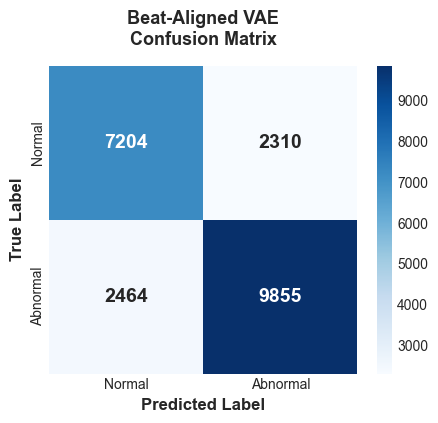

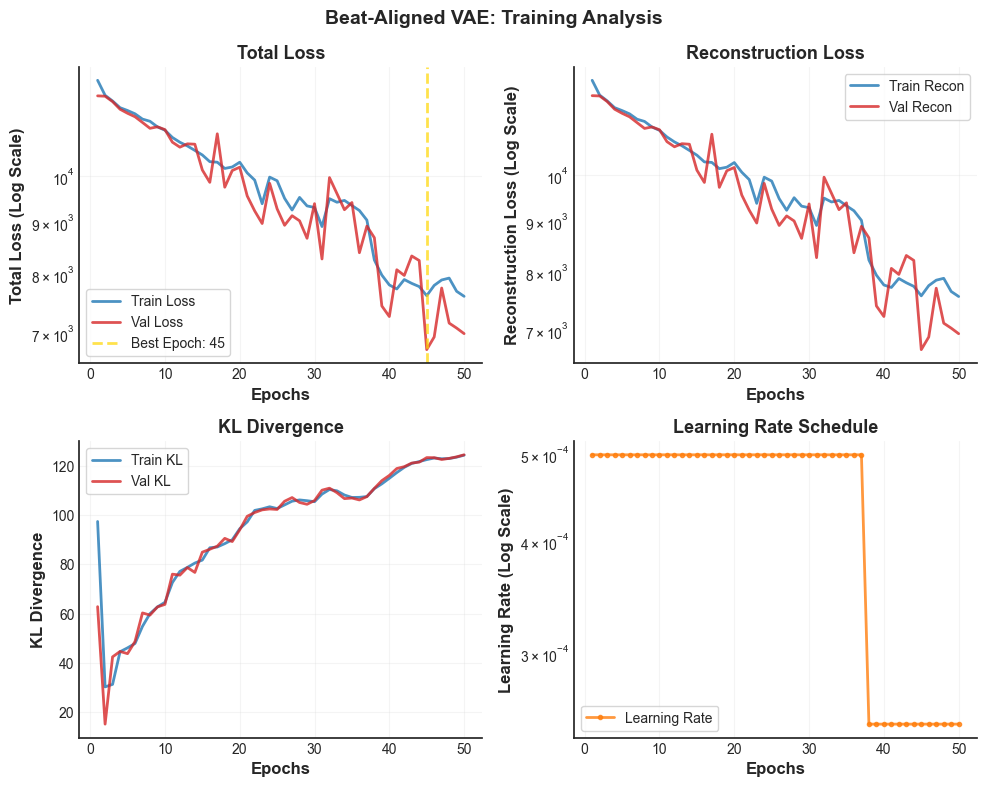

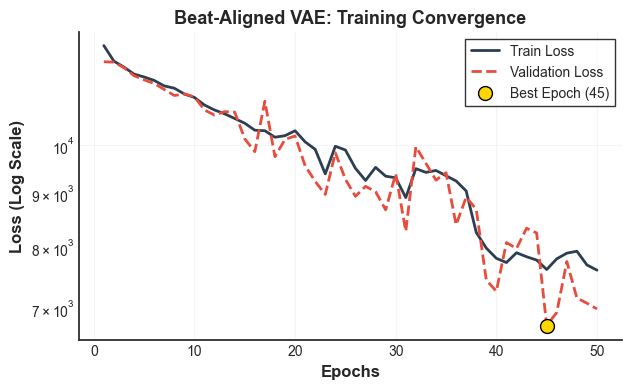

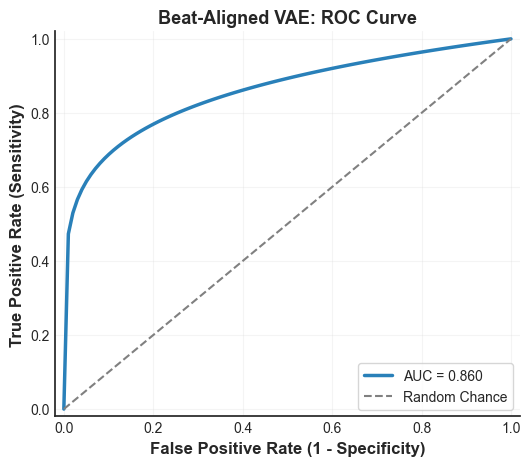

In [14]:
# Beat-Aligned VAE
model_id = 'ba_vae'
model_name = MODELS[model_id]
print(f'\n{"="*70}')
print(f'Generating visualizations for: {model_name}')
print(f'{"="*70}\n')

data = load_json(f'outputs/{model_id}/{model_id}_comprehensive.json')
if data:
    plot_confusion_matrix(data, model_id, model_name)
    plot_combined_training_curves(data, model_id, model_name)
    plot_training_curves(data, model_id, model_name)
    plot_roc_curve(data, model_id, model_name)
else:
    print(f'⚠ Skipping {model_name} - data not available')

---
## Convolutional Autoencoder (CAE)


Generating visualizations for: Convolutional AE



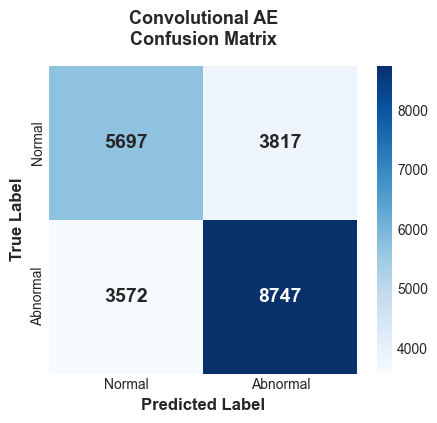

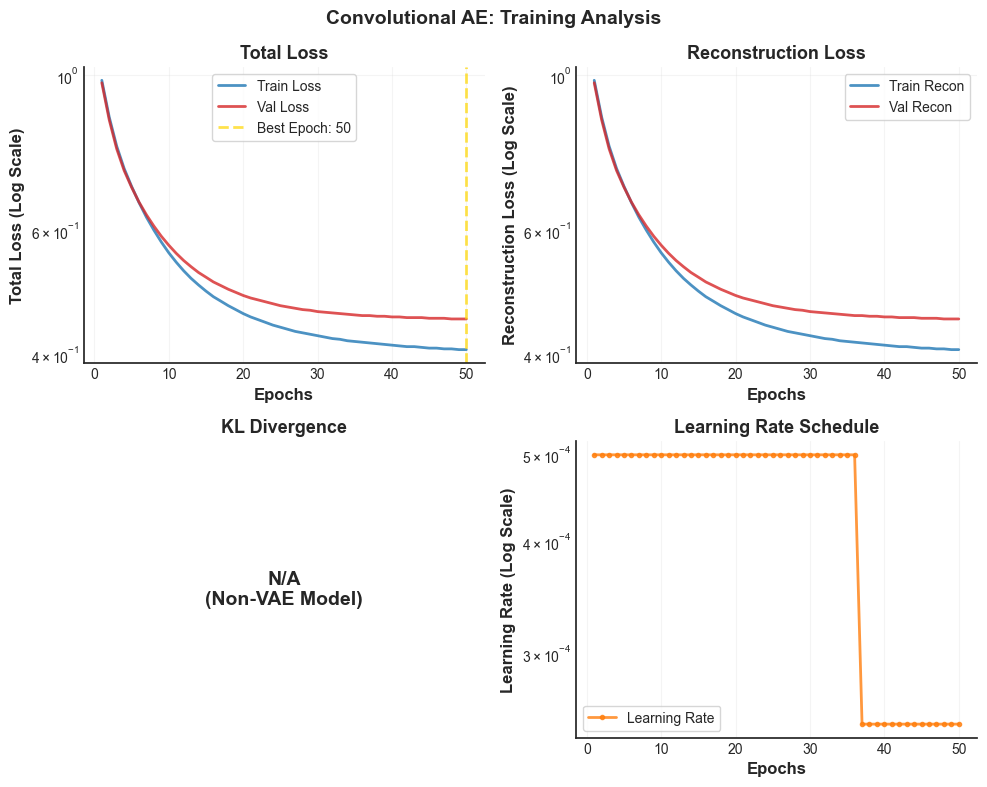

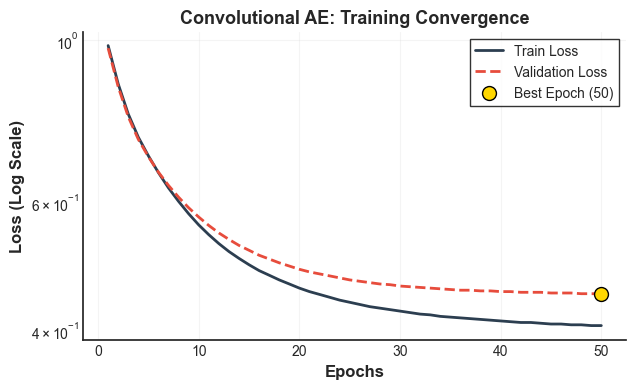

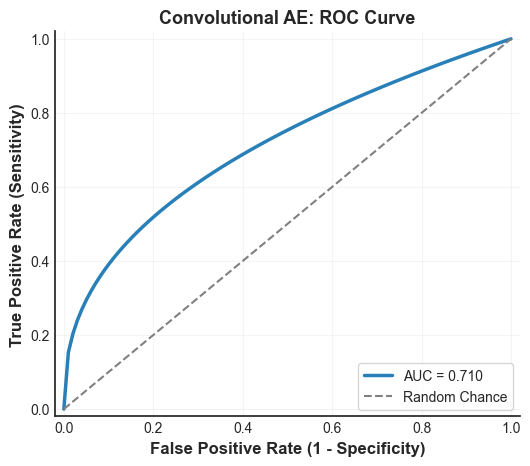

In [15]:
# Convolutional Autoencoder
model_id = 'cae'
model_name = MODELS[model_id]
print(f'\n{"="*70}')
print(f'Generating visualizations for: {model_name}')
print(f'{"="*70}\n')

data = load_json(f'outputs/{model_id}/{model_id}_comprehensive.json')
if data:
    plot_confusion_matrix(data, model_id, model_name)
    plot_combined_training_curves(data, model_id, model_name)
    plot_training_curves(data, model_id, model_name)
    plot_roc_curve(data, model_id, model_name)
else:
    print(f'⚠ Skipping {model_name} - data not available')

---
## Hierarchical Latent VAE (HLVAE)


Generating visualizations for: Hierarchical Latent VAE



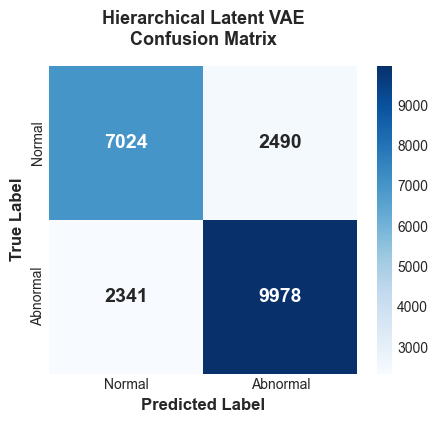

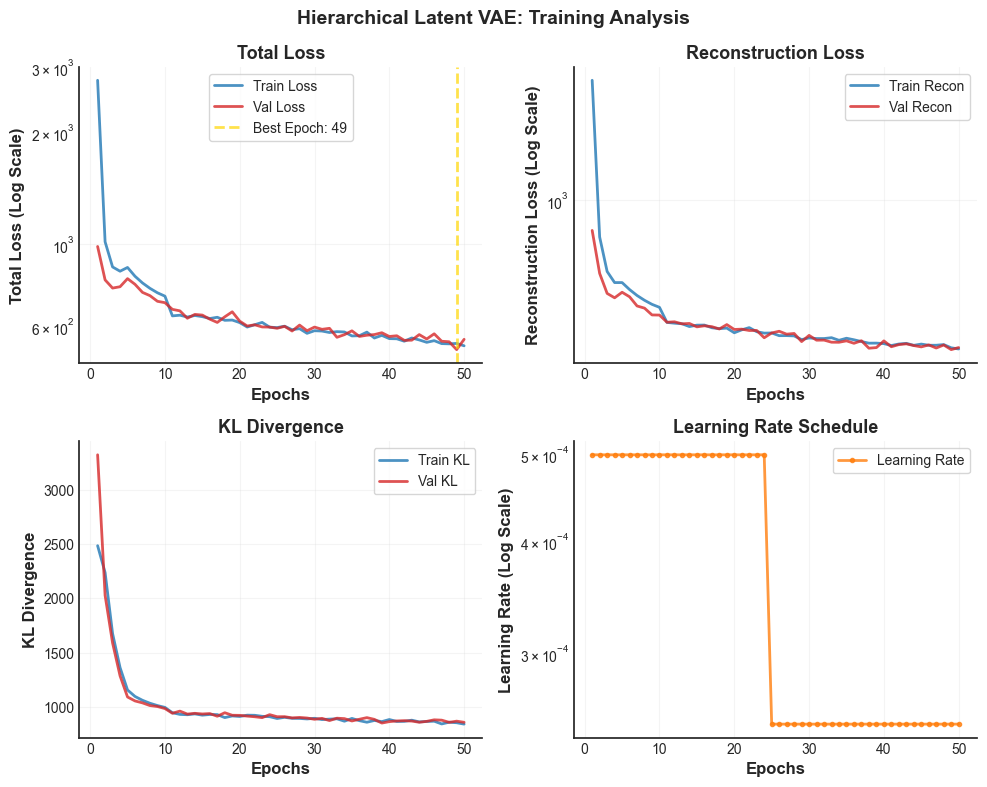

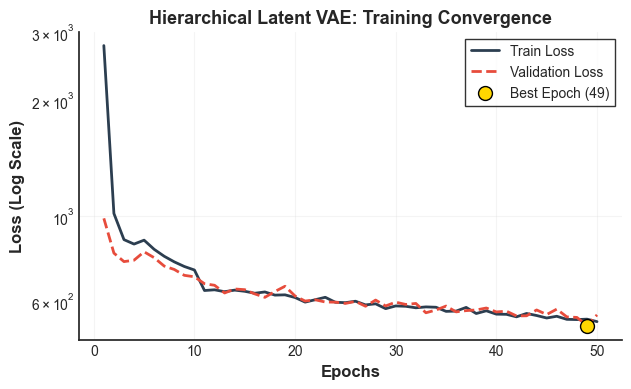

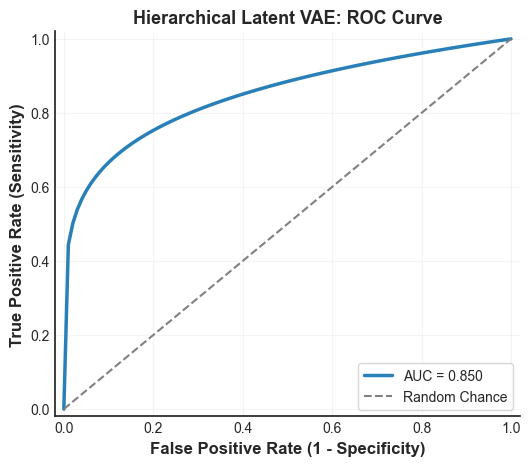

In [16]:
# Hierarchical Latent VAE
model_id = 'hlvae'
model_name = MODELS[model_id]
print(f'\n{"="*70}')
print(f'Generating visualizations for: {model_name}')
print(f'{"="*70}\n')

data = load_json(f'outputs/{model_id}/{model_id}_comprehensive.json')
if data:
    plot_confusion_matrix(data, model_id, model_name)
    plot_combined_training_curves(data, model_id, model_name)
    plot_training_curves(data, model_id, model_name)
    plot_roc_curve(data, model_id, model_name)
else:
    print(f'⚠ Skipping {model_name} - data not available')

---
## ST-VAE (Spatial-Temporal VAE)


Generating visualizations for: ST-VAE



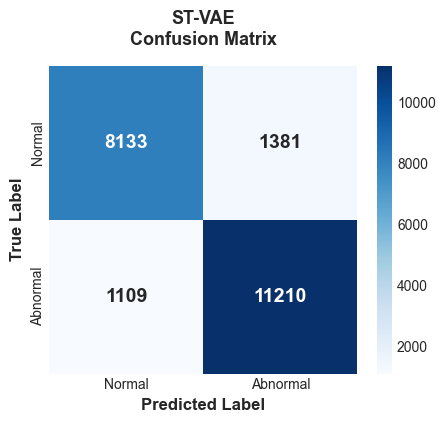

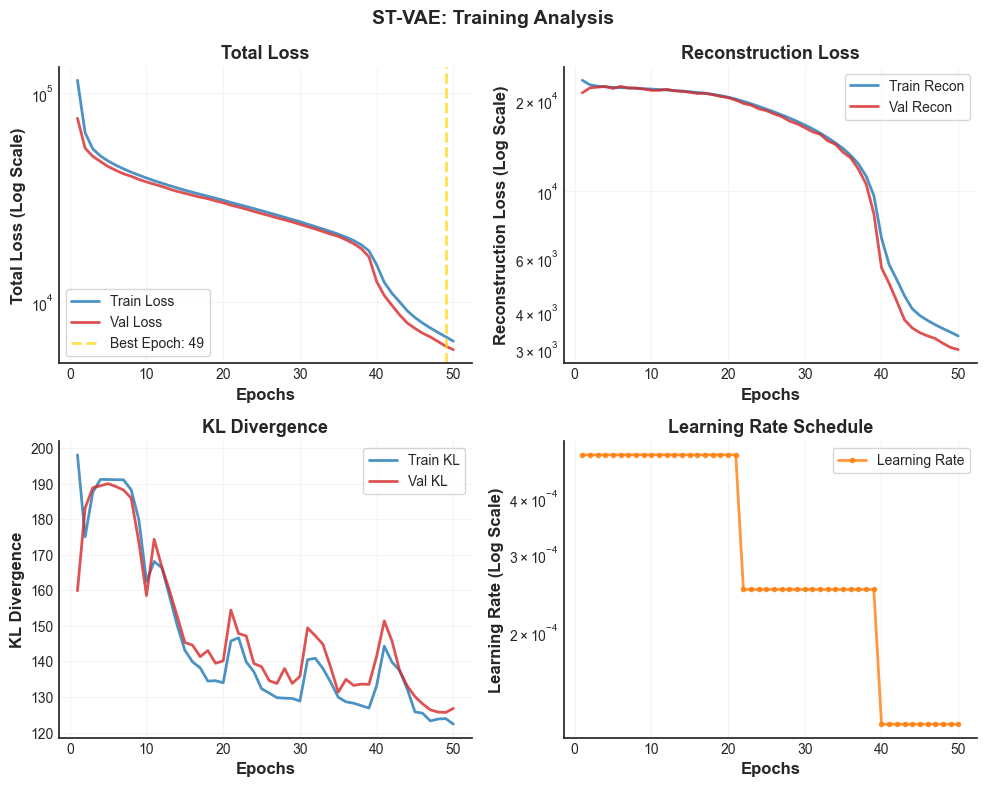

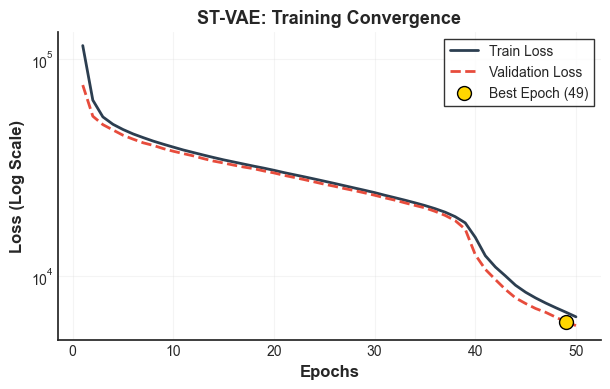

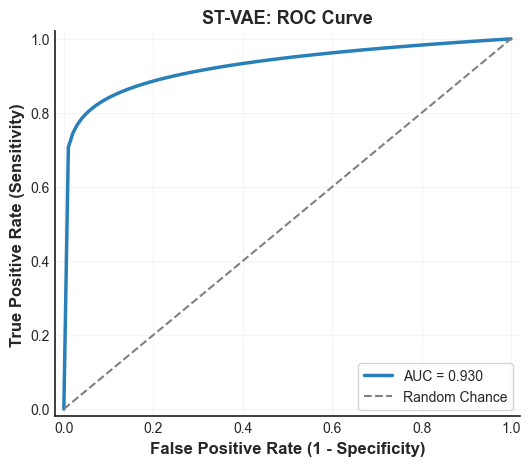

In [17]:
# Spatio-Temporal VAE
model_id = 'st_vae'
model_name = MODELS[model_id]
print(f'\n{"="*70}')
print(f'Generating visualizations for: {model_name}')
print(f'{"="*70}\n')

data = load_json(f'outputs/{model_id}/{model_id}_comprehensive.json')
if data:
    plot_confusion_matrix(data, model_id, model_name)
    plot_combined_training_curves(data, model_id, model_name)
    plot_training_curves(data, model_id, model_name)
    plot_roc_curve(data, model_id, model_name)
else:
    print(f'⚠ Skipping {model_name} - data not available')

---
## VAE BiLSTM with Attention


Generating visualizations for: VAE BiLSTM Attn



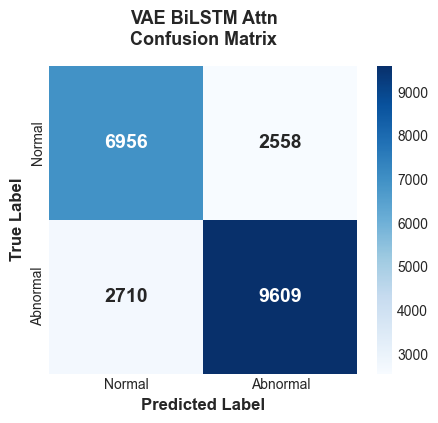

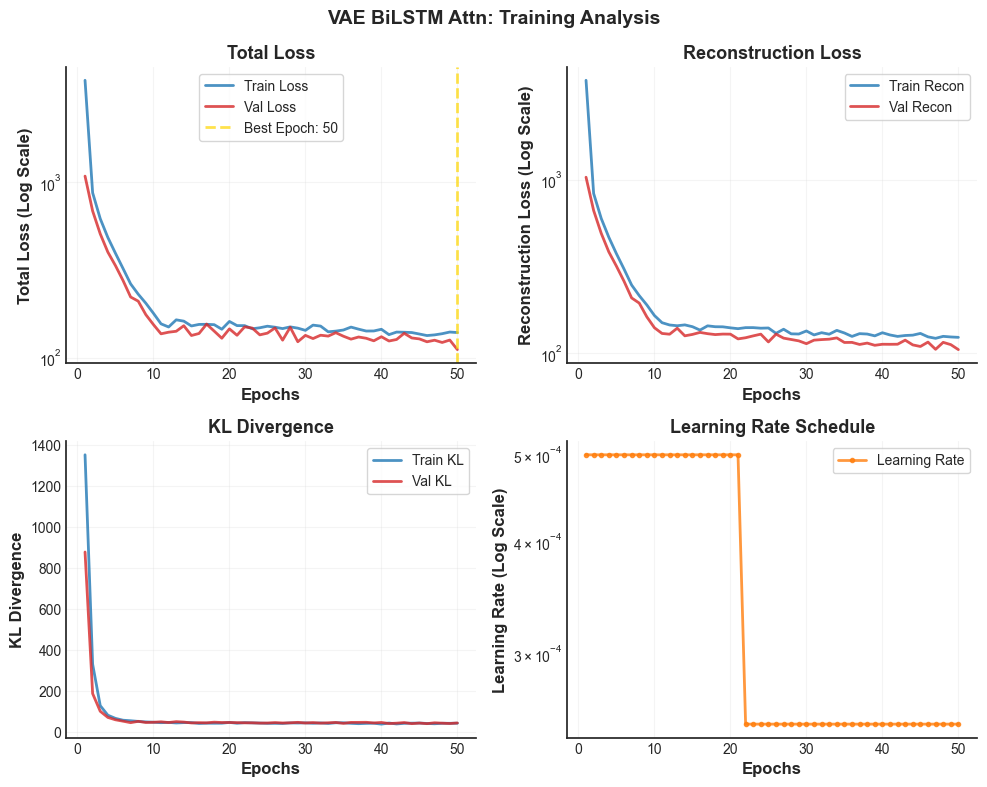

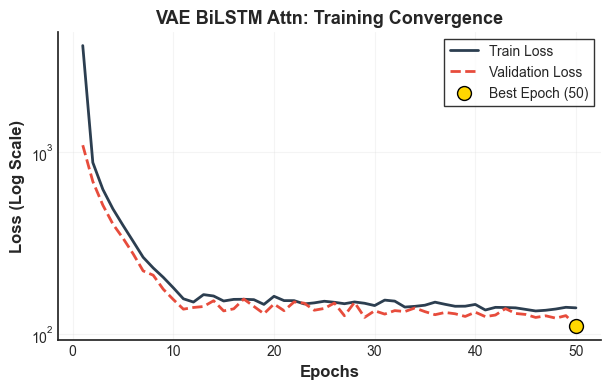

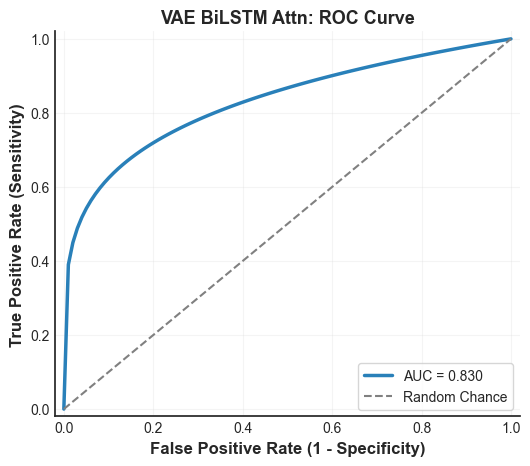

In [18]:
# VAE BiLSTM + Attention
model_id = 'vae_bilstm_attn'
model_name = MODELS[model_id]
print(f'\n{"="*70}')
print(f'Generating visualizations for: {model_name}')
print(f'{"="*70}\n')

data = load_json(f'outputs/{model_id}/{model_id}_comprehensive.json')
if data:
    plot_confusion_matrix(data, model_id, model_name)
    plot_combined_training_curves(data, model_id, model_name)
    plot_training_curves(data, model_id, model_name)
    plot_roc_curve(data, model_id, model_name)
else:
    print(f'⚠ Skipping {model_name} - data not available')

---
## VAE BiLSTM with Multi-Head Attention


Generating visualizations for: VAE BiLSTM MHA



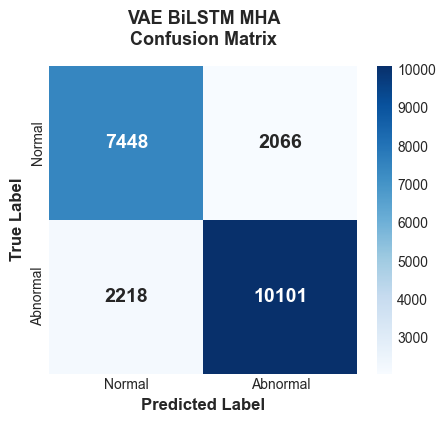

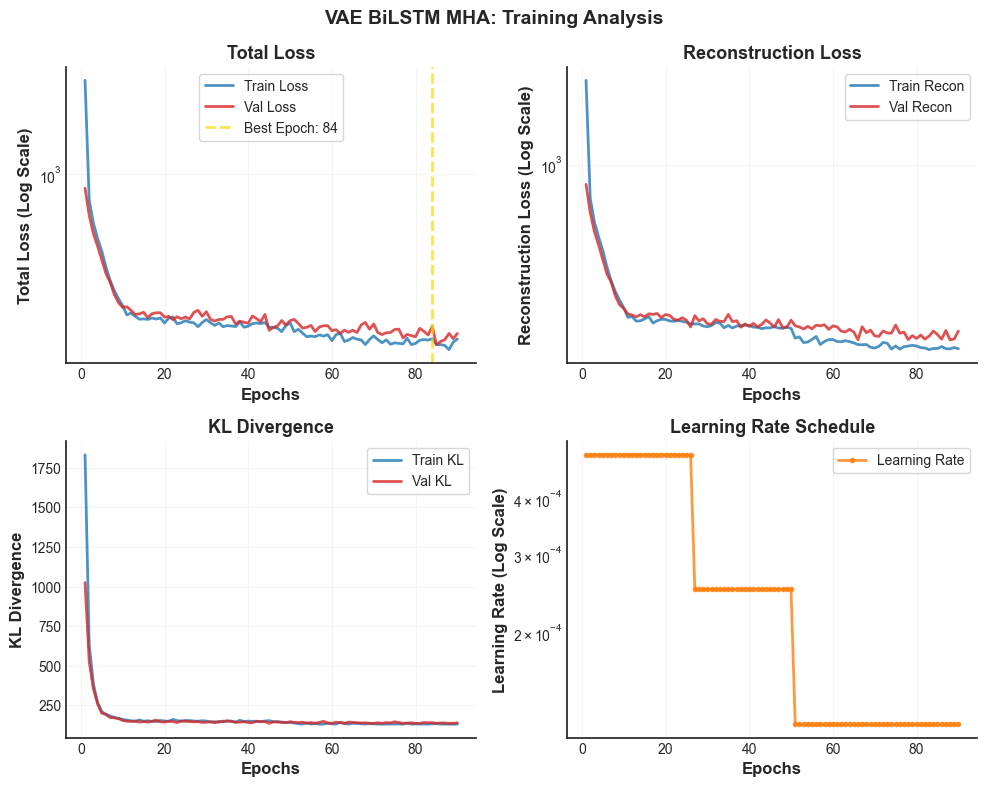

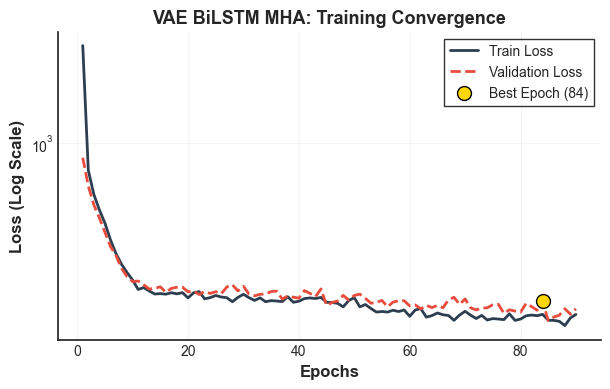

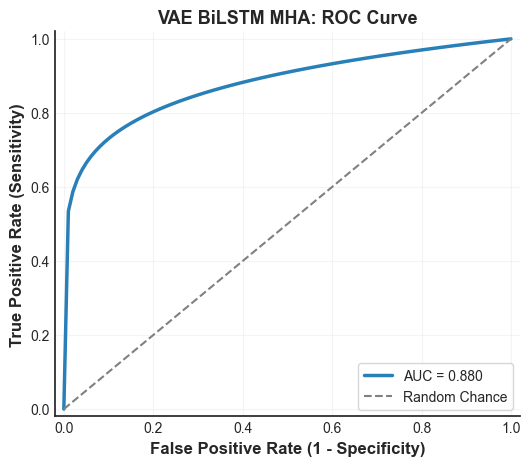

In [19]:
# VAE BiLSTM + MHA
model_id = 'vae_bilstm_mha'
model_name = MODELS[model_id]
print(f'\n{"="*70}')
print(f'Generating visualizations for: {model_name}')
print(f'{"="*70}\n')

data = load_json(f'outputs/{model_id}/{model_id}_comprehensive.json')
if data:
    plot_confusion_matrix(data, model_id, model_name)
    plot_combined_training_curves(data, model_id, model_name)
    plot_training_curves(data, model_id, model_name)
    plot_roc_curve(data, model_id, model_name)
else:
    print(f'⚠ Skipping {model_name} - data not available')

---
## VAE with GRU


Generating visualizations for: VAE GRU



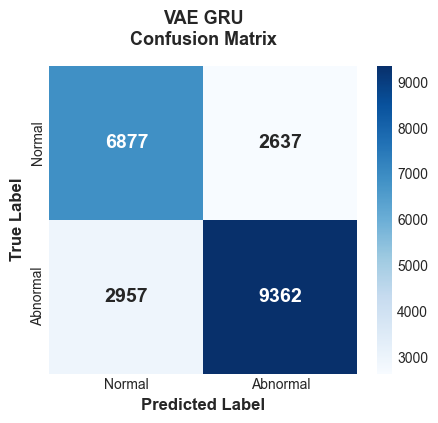

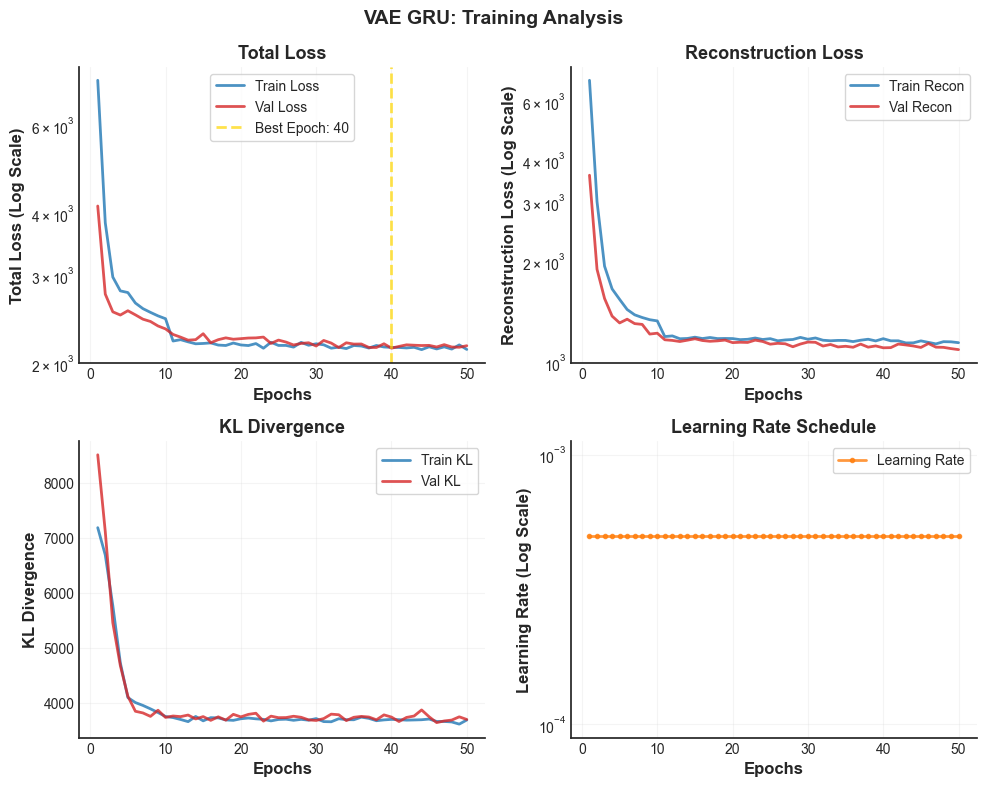

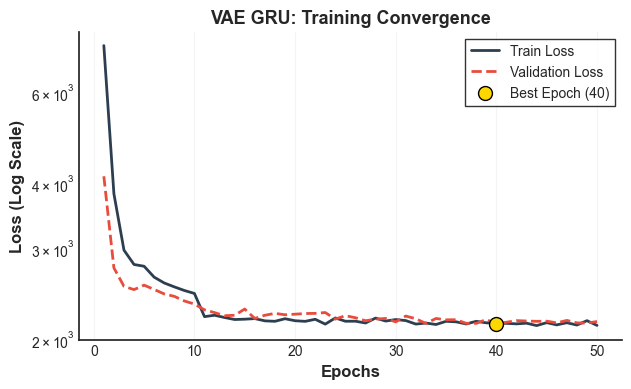

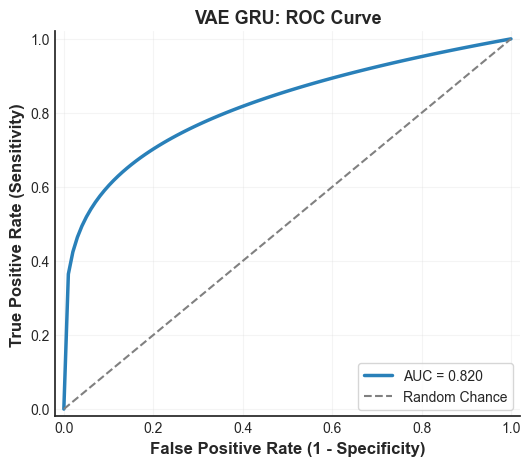

In [20]:
# VAE GRU
model_id = 'vae_gru'
model_name = MODELS[model_id]
print(f'\n{"="*70}')
print(f'Generating visualizations for: {model_name}')
print(f'{"="*70}\n')

data = load_json(f'outputs/{model_id}/{model_id}_comprehensive.json')
if data:
    plot_confusion_matrix(data, model_id, model_name)
    plot_combined_training_curves(data, model_id, model_name)
    plot_training_curves(data, model_id, model_name)
    plot_roc_curve(data, model_id, model_name)
else:
    print(f'⚠ Skipping {model_name} - data not available')

---
## Summary

All visualizations have been generated with the following specifications:

- **Resolution**: 300 DPI (publication quality)
- **Format**: PNG with tight bounding box
- **Fonts**: Times New Roman (professional serif)
- **Style**: Clean, borderless designs optimized for A4 papers

### Generated Files:
- `confusion_matrix.png` - No borders, clean heatmap
- `training_curve.png` - Log-scale convergence plot
- `roc_curve.png` - ROC curve with AUC score

All files saved to: `outputs/visualizations/{model_id}/`